In [13]:
#!pip install fasttext
!pip install fasttext-wheel
!pip install scikit-learn
!pip install imbalanced-learn

In [14]:
import fasttext
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


In [19]:
train_df = pd.read_csv('C:/Users/User/Desktop/NLP/ass 1/train_data.csv')
test_df = pd.read_csv('C:/Users/User/Desktop/NLP/ass 1/test_data.csv')

train_sample = train_df.sample(frac=0.2, random_state=42)
test_sample = test_df.sample(frac=0.2, random_state=42)

print("Train Sample Preview:")
print(train_sample.head())

print("\nTest Sample Preview:")
print(test_sample.head())

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stopwords.words('english')]  # Lemmatize and remove stopwords
    return ' '.join(words)


train_sample['cleaned_text'] = train_sample['Tweet'].apply(clean_text)
test_sample['cleaned_text'] = test_sample['Tweet'].apply(clean_text)


Train Sample Preview:
                                                   Tweet  Sentiment_Label
3111   il ne vous vient pas ã lesprit que les merdias...                2
18679  canadians are fighting for freedom in ukraineâ...                2
17472  freedom convoy heroic speech by canadian army ...                2
21451  theres a teamsters strike going on in seattle ...                2
20800  all those who gave money to the freedom convoy...                0

Test Sample Preview:
                                                  Tweet  Sentiment_Label
1782  the freedom convoy was terrorism an attack on ...                0
3917  wheels of freedom american truckers set to lau...                2
221   believe pm may believe he should be the one âh...                2
2135  at no point did the service csis assess that t...                0
5224  pierre poilievre is on the same path that trum...                2


In [22]:
# Save the cleaned text data to a temporary .txt file
train_text_file = 'C:/Users/User/Desktop/NLP/ass 1/train_data.csv.txt'

with open(train_text_file, 'w') as f:
    for text in train_sample['cleaned_text']:
        f.write(f"{text}\n")

ft_model = fasttext.train_unsupervised(train_text_file, model='skipgram')


In [31]:
import numpy as np
from imblearn.over_sampling import SMOTE

# Function to get the FastText vector for each word in the text
def get_fasttext_vector(text, model):
    words = text.split()  
    vectors = [model.get_word_vector(word) for word in words if word in model] 
    if vectors:
        return np.mean(vectors, axis=0)  
    else:
        return np.zeros(model.get_dimension())  

# Vectorizing the text in the training and test samples using FastText
X_train = np.array([get_fasttext_vector(text, ft_model) for text in train_sample['cleaned_text']])
X_test = np.array([get_fasttext_vector(text, ft_model) for text in test_sample['cleaned_text']])

# Extracting the sentiment labels
y_train = train_sample['Sentiment_Label']
y_test = test_sample['Sentiment_Label']

# Check if the vectors have consistent shape
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

# Apply SMOTE for oversampling the minority class in the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Verify the resampling
print(f"Shape of resampled X_train: {X_train_resampled.shape}")
print(f"Shape of resampled y_train: {y_train_resampled.shape}")

Shape of X_train: (4800, 100)
Shape of X_test: (1200, 100)
Shape of resampled X_train: (4959, 100)
Shape of resampled y_train: (4959,)


## SVM using Fasttext

In [34]:
# Initialize the SVM model (use a linear kernel for faster performance)
svm_model = SVC(kernel='linear', random_state=42)

# Train the model
svm_model.fit(X_train_resampled, y_train_resampled)

# Predict on the test data
y_pred = svm_model.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.79      0.55       420
           1       0.67      0.09      0.16       372
           2       0.45      0.41      0.43       408

    accuracy                           0.44      1200
   macro avg       0.52      0.43      0.38      1200
weighted avg       0.51      0.44      0.39      1200

Confusion Matrix:
[[331   3  86]
 [220  33 119]
 [228  13 167]]


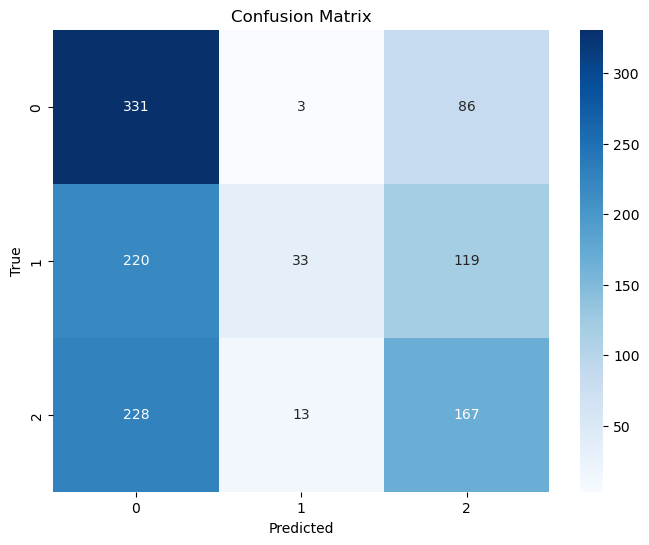

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Model Tuning

In [39]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear'],
    'gamma': ['scale']
}

# Initialize the SVM model
svm_model = SVC()

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=1, scoring='accuracy')

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Get the best model
best_svm_model = grid_search.best_estimator_


Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation Score: 0.4502083333333333


In [41]:
y_pred = best_svm_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.82      0.58       420
           1       0.71      0.10      0.17       372
           2       0.51      0.49      0.50       408

    accuracy                           0.48      1200
   macro avg       0.56      0.47      0.42      1200
weighted avg       0.55      0.48      0.43      1200

Confusion Matrix:
[[343   4  73]
 [213  37 122]
 [198  11 199]]


In [43]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Define the parameter distribution for SVM
param_dist = {
    'C': np.logspace(-3, 3, 7),
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Initialize the SVM model
svm_model = SVC()

# Initialize RandomizedSearchCV with cross-validation
random_search = RandomizedSearchCV(estimator=svm_model, param_distributions=param_dist,
                                   n_iter=100, cv=5, n_jobs=-1, verbose=1, scoring='accuracy', random_state=42)

# Fit the random search to the training data
random_search.fit(X_train, y_train)

# Get the best parameters and best score
print("Best Parameters from RandomizedSearchCV:", random_search.best_params_)
print("Best Cross-Validation Score from RandomizedSearchCV:", random_search.best_score_)

# Get the best model
best_svm_model_random = random_search.best_estimator_

# Predict using the best model
y_pred_random = best_svm_model_random.predict(X_test)

# Evaluate the model
print("Classification Report for RandomizedSearchCV:")
print(classification_report(y_test, y_pred_random))

print("Confusion Matrix for RandomizedSearchCV:")
print(confusion_matrix(y_test, y_pred_random))


C:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 28 is smaller than n_iter=100. Running 28 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best Parameters from RandomizedSearchCV: {'kernel': 'rbf', 'gamma': 'scale', 'C': 1000.0}
Best Cross-Validation Score from RandomizedSearchCV: 0.516875
Classification Report for RandomizedSearchCV:
              precision    recall  f1-score   support

           0       0.50      0.73      0.60       420
           1       0.55      0.24      0.34       372
           2       0.55      0.58      0.56       408

    accuracy                           0.53      1200
   macro avg       0.53      0.52      0.50      1200
weighted avg       0.53      0.53      0.50      1200

Confusion Matrix for RandomizedSearchCV:
[[305  37  78]
 [163  91 118]
 [137  36 235]]


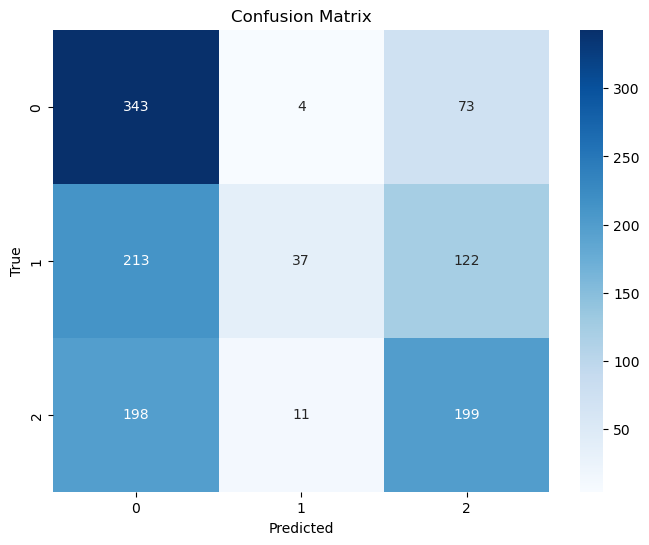

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### LLM Prompts
- how to do resamplinng
- fastext code for jupyter
- how to do SVM tuning 